In [135]:
import pandas as pd
import numpy as np

# --- Load data ---
df = pd.read_excel('master_panel_.xlsx')

# --- Convert numeric columns ---
numeric_columns = [
    'Government_Effectiveness', 'Regulatory_Quality', 'GDP', 'Labour_Force_Total',
    'Tax_Revenue_GDP', 'Agriculture_GDP', 'Trade_Openness_GDP', 
    'Digitalization_InternetUsers', 'Remittances_GDP', 'Inflation','Human_Capital_index',
    'Unemployment_Rate', 'Rule_of_Law', 'Corruption_Perception_Index'
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
df=df.drop(columns=["ISO3"])
print(df.head(20))

    Country  Year  Government_Effectiveness  Regulatory_Quality           GDP  \
0   Albania  1995                       NaN                 NaN  4.969648e+09   
1   Albania  1996                 -0.688588           -0.684482  5.334238e+09   
2   Albania  1997                       NaN                 NaN  4.709515e+09   
3   Albania  1998                 -0.732603           -0.929672  5.100877e+09   
4   Albania  1999                       NaN                 NaN  5.725771e+09   
5   Albania  2000                 -0.917780           -1.020668  6.153077e+09   
6   Albania  2001                       NaN                 NaN  6.698469e+09   
7   Albania  2002                 -0.624333           -0.762321  7.008501e+09   
8   Albania  2003                 -0.563987           -0.716323  7.382283e+09   
9   Albania  2004                 -0.408372           -0.701032  7.771053e+09   
10  Albania  2005                 -0.696387           -0.763833  8.169772e+09   
11  Albania  2006           

In [136]:
print(df.columns.tolist())
print(df.head())
print(df.info())

['Country', 'Year', 'Government_Effectiveness', 'Regulatory_Quality', 'GDP', 'Labour_Force_Total', 'Tax_Revenue_GDP', 'Agriculture_GDP', 'Trade_Openness_GDP', 'Human_Capital_index', 'Digitalization_InternetUsers', 'Remittances_GDP', 'Inflation', 'Unemployment_Rate', 'Rule_of_Law', 'Corruption_Perception_Index']
   Country  Year  Government_Effectiveness  Regulatory_Quality           GDP  \
0  Albania  1995                       NaN                 NaN  4.969648e+09   
1  Albania  1996                 -0.688588           -0.684482  5.334238e+09   
2  Albania  1997                       NaN                 NaN  4.709515e+09   
3  Albania  1998                 -0.732603           -0.929672  5.100877e+09   
4  Albania  1999                       NaN                 NaN  5.725771e+09   

   Labour_Force_Total  Tax_Revenue_GDP  Agriculture_GDP  Trade_Openness_GDP  \
0             1363787        11.202220        32.837450           40.138699   
1             1345509         8.766251        33

In [137]:
# --- Compute Inflation Rate ---
df = df.sort_values(['Country','Year'])

if 'Inflation' in df.columns:
    df['Inflation_Rate'] = df.groupby('Country')['Inflation'].pct_change() * 100
    df = df.drop(columns=['Inflation'])
else:
    df['Inflation_Rate'] = np.nan

# --- Compute GDP per Worker ---
df['GDP_per_Worker'] = df['GDP'] / df['Labour_Force_Total']
df.loc[np.isinf(df['GDP_per_Worker']), 'GDP_per_Worker'] = np.nan
df = df.drop(columns=[col for col in ['Labour_Force_Total'] if col in df.columns])
# Add derived indicators to numeric list
numeric_columns += ['Inflation_Rate', 'GDP_per_Worker']
# Recompute available columns
available_numeric_cols = [c for c in numeric_columns if c in df.columns]

print(df.head())


   Country  Year  Government_Effectiveness  Regulatory_Quality           GDP  \
0  Albania  1995                       NaN                 NaN  4.969648e+09   
1  Albania  1996                 -0.688588           -0.684482  5.334238e+09   
2  Albania  1997                       NaN                 NaN  4.709515e+09   
3  Albania  1998                 -0.732603           -0.929672  5.100877e+09   
4  Albania  1999                       NaN                 NaN  5.725771e+09   

   Tax_Revenue_GDP  Agriculture_GDP  Trade_Openness_GDP  Human_Capital_index  \
0        11.202220        32.837450           40.138699                  NaN   
1         8.766251        33.561661           44.411782                  NaN   
2         9.753038        28.941315           44.729378             2.634504   
3        14.264201        26.261043           47.130627             2.688920   
4        14.279235        23.622567           49.895418             2.744460   

   Digitalization_InternetUsers  Remit

/var/folders/cm/9zmmwzc1561gyy_v8z4z_k080000gn/T/ipykernel_5689/3699463551.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Inflation_Rate'] = df.groupby('Country')['Inflation'].pct_change() * 100


In [138]:
# --- Filter years and countries ---
turning_year = 2000
df = df[df["Year"] >= turning_year].reset_index(drop=True)

id_cols = ["Country", "Year"]
vars_cols = [c for c in df.columns if c not in id_cols]

# Country coverage
country_coverage = (
    df.groupby("Country")[vars_cols]
      .apply(lambda x: x.notna().sum().sum() / (x.shape[0] * x.shape[1]))
)

# Convert to DataFrame
country_coverage = country_coverage.reset_index(name="Coverage")

# Show coverage sorted
print("\nCountry coverage (sorted):")
print(country_coverage.sort_values("Coverage", ascending=False))

# Apply threshold
country_threshold = 0.8
countries_keep = country_coverage[country_coverage["Coverage"] >= country_threshold]["Country"]

# Countries dropped
countries_dropped = set(country_coverage["Country"]) - set(countries_keep)

print(f"\nCountries kept (coverage ≥ {country_threshold*100}%):")
print(countries_keep.tolist())
print(f"Number of countries kept: {len(countries_keep)}")

print(f"\nCountries dropped (coverage < {country_threshold*100}%):")
print(sorted(countries_dropped))
print(f"Number of countries dropped: {len(countries_dropped)}")

# Filter dataset
df = df[df["Country"].isin(countries_keep)].reset_index(drop=True)

# Save filtered dataset
df.to_excel('filtered_data_2000.xlsx', index=False, sheet_name='Data')
print(df.columns.tolist())
print(df.head())
print(df.info())





Country coverage (sorted):
                   Country  Coverage
18                Slovenia  0.980000
3                 Bulgaria  0.980000
15                 Romania  0.980000
10                  Latvia  0.977143
4                  Croatia  0.977143
6           Czech Republic  0.977143
7                  Estonia  0.977143
8                   Greece  0.977143
17                Slovakia  0.977143
14                  Poland  0.974286
9                  Hungary  0.974286
11               Lithuania  0.974286
12                 Moldova  0.974286
5                   Cyprus  0.962857
19                  Turkey  0.957143
0                  Albania  0.954286
16                  Serbia  0.914286
1                  Belarus  0.908571
13         North Macedonia  0.880000
2   Bosnia and Herzegovina  0.868571

Countries kept (coverage ≥ 80.0%):
['Albania', 'Belarus', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Estonia', 'Greece', 'Hungary', 'Latvia', 'Lithuania', 'Mol

In [139]:
# --- Evaluate missing data for 2024 ---
df_2024 = df[df['Year'] == 2024].copy()

if not df_2024.empty:
    print("\n" + "="*60)
    print("2024 DATA AVAILABILITY ANALYSIS")
    print("="*60)

    total_features = len(vars_cols)
    total_countries = len(df_2024)
    total_cells = total_countries * total_features

    missing_per_feature = df_2024[vars_cols].isnull().sum()
    available_per_feature = total_countries - missing_per_feature

    missing_cells = missing_per_feature.sum()
    available_cells = total_cells - missing_cells
    missing_pct = (missing_cells / total_cells) * 100

    # Overall summary
    print(f"\nCountries: {total_countries}, Features: {total_features}")
    print(f"Available: {available_cells}/{total_cells} ({available_cells/total_cells*100:.1f}%)")
    print(f"Missing:   {missing_cells}/{total_cells} ({missing_pct:.1f}%)")

    # Feature-level breakdown
    print(f"\n{'Feature':<40} {'Available':<12} {'Missing':<12} {'% Available':<12}")
    print("-"*80)
    for col in vars_cols:
        avail, miss = available_per_feature[col], missing_per_feature[col]
        pct = (avail / total_countries) * 100
        print(f"{col:<40} {avail:<12} {miss:<12} {pct:<12.1f}%")

    # Categories
    fully_available = (missing_per_feature == 0).sum()
    partially_missing = ((missing_per_feature > 0) & (missing_per_feature < total_countries)).sum()
    completely_missing = (missing_per_feature == total_countries).sum()

    print("\nFeature categories:")
    print(f"  Fully available: {fully_available}/{total_features}")
    print(f"  Partially missing: {partially_missing}/{total_features}")
    print(f"  Completely missing: {completely_missing}/{total_features}")

    if completely_missing > 0:
        print("\nCompletely missing features:")
        for feat in missing_per_feature[missing_per_feature == total_countries].index:
            print(f"  - {feat}")

    # Recommendation
    print("\nRecommendation:")
    if missing_pct < 30:
        print(f" Missing {missing_pct:.1f}% → Extrapolate and INCLUDE 2024 in training")
    elif missing_pct < 50:
        print(f" Missing {missing_pct:.1f}% → Either extrapolate and include, or exclude as holdout test")
    else:
        print(f" Missing {missing_pct:.1f}% → EXCLUDE 2024 from training, use as holdout test set")
else:
    print("\nNo data found for 2024 (possibly dropped during coverage filtering)")



2024 DATA AVAILABILITY ANALYSIS

Countries: 20, Features: 14
Available: 181/280 (64.6%)
Missing:   99/280 (35.4%)

Feature                                  Available    Missing      % Available 
--------------------------------------------------------------------------------
Government_Effectiveness                 1            19           5.0         %
Regulatory_Quality                       0            20           0.0         %
GDP                                      20           0            100.0       %
Tax_Revenue_GDP                          4            16           20.0        %
Agriculture_GDP                          20           0            100.0       %
Trade_Openness_GDP                       20           0            100.0       %
Human_Capital_index                      0            20           0.0         %
Digitalization_InternetUsers             16           4            80.0        %
Remittances_GDP                          20           0            100.0   

In [140]:
# --- Interpolation for 2001 ---
df_interp = df.copy()

for country in df_interp['Country'].unique():
    country_data = df_interp[df_interp['Country'] == country]
    years = country_data['Year'].values
    
    if 2000 in years and 2002 in years:
        val_2000 = country_data.loc[country_data['Year'] == 2000].iloc[0]
        val_2002 = country_data.loc[country_data['Year'] == 2002].iloc[0]
        
        # Interpolate selected governance indicators
        interp_values = {}
        if country != 'Montenegro' and 'Government_Effectiveness' in country_data.columns:
            interp_values['Government_Effectiveness'] = (val_2000['Government_Effectiveness'] + val_2002['Government_Effectiveness']) / 2
        if 'Regulatory_Quality' in country_data.columns:
            interp_values['Regulatory_Quality'] = (val_2000['Regulatory_Quality'] + val_2002['Regulatory_Quality']) / 2
        if 'Rule_of_Law' in country_data.columns:
            interp_values['Rule_of_Law'] = (val_2000['Rule_of_Law'] + val_2002['Rule_of_Law']) / 2
        
        # Update or insert 2001 row
        row_idx = df_interp[(df_interp['Country'] == country) & (df_interp['Year'] == 2001)].index
        if len(row_idx) > 0:
            for col, val in interp_values.items():
                df_interp.loc[row_idx[0], col] = val
        else:
            new_row = val_2000.copy()
            new_row['Year'] = 2001
            for col, val in interp_values.items():
                new_row[col] = val
            # Set other numeric columns to NaN
            numeric_cols_except = [
                col for col in df_interp.columns 
                if col not in ['Country','Year'] + list(interp_values.keys()) 
                and pd.api.types.is_numeric_dtype(df_interp[col])
            ]
            for col in numeric_cols_except:
                new_row[col] = np.nan
            df_interp = pd.concat([df_interp, pd.DataFrame([new_row])], ignore_index=True)

# --- Estimate 2024 for Digitalization_InternetUsers using last 3 years growth ---
df_2024 = df_interp.copy()

for country in df_2024['Country'].unique():
    country_data = df_2024[df_2024['Country'] == country]
    if 'Digitalization_InternetUsers' in country_data.columns:
        last3 = country_data[country_data['Year'].between(2021, 2023)]['Digitalization_InternetUsers']
        if last3.notna().sum() >= 2:
            growth_rates = last3.pct_change().dropna()
            if not growth_rates.empty:
                avg_growth = growth_rates.mean()
                val_2023 = last3.iloc[-1]
                val_2024 = val_2023 * (1 + avg_growth)
                row_idx = df_2024[(df_2024['Country'] == country) & (df_2024['Year'] == 2024)].index
                if len(row_idx) > 0:
                    df_2024.loc[row_idx[0], 'Digitalization_InternetUsers'] = val_2024
                else:
                    new_row = country_data[country_data['Year'] == 2023].iloc[0].copy()
                    new_row['Year'] = 2024
                    new_row['Digitalization_InternetUsers'] = val_2024
                    df_2024 = pd.concat([df_2024, pd.DataFrame([new_row])], ignore_index=True)

# --- Final sort ---
df = df_2024.sort_values(['Country','Year']).reset_index(drop=True)
print(df.columns.tolist())
print(df.head())
print(df.info())


['Country', 'Year', 'Government_Effectiveness', 'Regulatory_Quality', 'GDP', 'Tax_Revenue_GDP', 'Agriculture_GDP', 'Trade_Openness_GDP', 'Human_Capital_index', 'Digitalization_InternetUsers', 'Remittances_GDP', 'Unemployment_Rate', 'Rule_of_Law', 'Corruption_Perception_Index', 'Inflation_Rate', 'GDP_per_Worker']
   Country  Year  Government_Effectiveness  Regulatory_Quality           GDP  \
0  Albania  2000                 -0.917780           -1.020668  6.153077e+09   
1  Albania  2001                 -0.771057           -0.891495  6.698469e+09   
2  Albania  2002                 -0.624333           -0.762321  7.008501e+09   
3  Albania  2003                 -0.563987           -0.716323  7.382283e+09   
4  Albania  2004                 -0.408372           -0.701032  7.771053e+09   

   Tax_Revenue_GDP  Agriculture_GDP  Trade_Openness_GDP  Human_Capital_index  \
0              NaN        22.179014           61.609261             2.801147   
1              NaN        20.452405          

In [141]:
missing_summary = df.groupby('Country')['Tax_Revenue_GDP'].apply(lambda x: x.isna().sum())
print(missing_summary)


Country
Albania                   7
Belarus                   1
Bosnia and Herzegovina    6
Bulgaria                  0
Croatia                   1
Cyprus                    1
Czech Republic            1
Estonia                   1
Greece                    1
Hungary                   2
Latvia                    1
Lithuania                 1
Moldova                   1
North Macedonia           6
Poland                    1
Romania                   0
Serbia                    9
Slovakia                  1
Slovenia                  0
Turkey                    9
Name: Tax_Revenue_GDP, dtype: int64


Total observations: 500
Still missing (large gaps left): 25


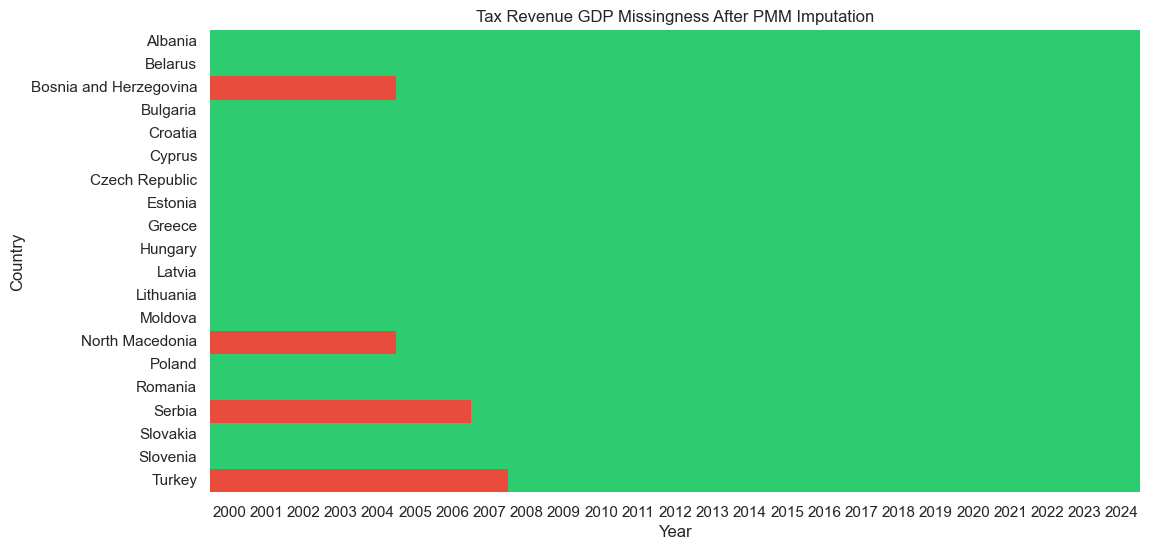

In [142]:
# ============================================================
# TAX_REVENUE_GDP IMPUTATION WITH TRUE PMM (ML-FRIENDLY VERSION)
# ============================================================
from sklearn.linear_model import BayesianRidge
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
df["TaxRev_missing"] = df["Tax_Revenue_GDP"].isna().astype(int)
# ------------------------------------------------------------
# TRUE PMM FUNCTION
# ------------------------------------------------------------
def pmm_impute(df_sub, target_col, predictor_cols, k_neighbors=5, random_state=42):
    np.random.seed(random_state)
    obs_mask = df_sub[target_col].notna()
    miss_mask = ~obs_mask

    if miss_mask.sum() == 0:
        return df_sub[target_col]

    X_obs = df_sub.loc[obs_mask, predictor_cols]
    y_obs = df_sub.loc[obs_mask, target_col].values
    X_miss = df_sub.loc[miss_mask, predictor_cols]

    imputer = SimpleImputer(strategy='median')
    X_obs_filled = imputer.fit_transform(X_obs)
    X_miss_filled = imputer.transform(X_miss)

    model = BayesianRidge().fit(X_obs_filled, y_obs)
    y_pred_obs = model.predict(X_obs_filled)
    y_pred_miss = model.predict(X_miss_filled)

    imputed_vals = []
    for pred in y_pred_miss:
        neighbors = np.argsort(np.abs(y_pred_obs - pred))[:k_neighbors]
        imputed_vals.append(np.random.choice(y_obs[neighbors]))

    result = df_sub[target_col].copy()
    result.loc[miss_mask] = imputed_vals
    return result

# ------------------------------------------------------------
# STEP 1: Detect consecutive missing blocks (helper)
# ------------------------------------------------------------
def find_consecutive_missing_blocks(series):
    blocks = []
    current_start, length = None, 0
    for i, is_missing in enumerate(series.isnull()):
        if is_missing:
            if current_start is None:
                current_start = i
            length += 1
        else:
            if length > 0:
                blocks.append((current_start, length))
            current_start, length = None, 0
    if length > 0:
        blocks.append((current_start, length))
    return blocks

# ------------------------------------------------------------
# STEP 2: Identify large-gap indices 
# ------------------------------------------------------------
large_gap_indices_global = []
small_gap_countries = []

for country in df['Country'].unique():
    cdata = df[df['Country'] == country].sort_values('Year').reset_index()
    blocks = find_consecutive_missing_blocks(cdata['Tax_Revenue_GDP'])
    for start, length in blocks:
        if length >= 5:
            idxs = cdata.loc[start:start+length-1, 'index'].tolist()
            large_gap_indices_global.extend(idxs)
        elif length <= 3:
            small_gap_countries.append(country)

large_gap_indices_global = set(large_gap_indices_global)

# ------------------------------------------------------------
# STEP 3: Apply PMM for small gaps (no flag columns saved)
# ------------------------------------------------------------
features = [
    'GDP', 'Agriculture_GDP', 'Trade_Openness_GDP',
    'Unemployment_Rate', 'Inflation_Rate', 'Government_Effectiveness'
]

for country in small_gap_countries:
    mask_country = (df['Country'] == country)
    # Within this country, exclude large-gap indices
    mask_valid = mask_country & (~df.index.isin(large_gap_indices_global))
    df.loc[mask_valid, 'Tax_Revenue_GDP'] = pmm_impute(
        df.loc[mask_valid],
        'Tax_Revenue_GDP',
        features
    )

# ------------------------------------------------------------
# STEP 4: Final stats
# ------------------------------------------------------------
print("Total observations:", len(df))
print("Still missing (large gaps left):", df['Tax_Revenue_GDP'].isnull().sum())

# ------------------------------------------------------------
# STEP 5: Visualization
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.heatmap(
    df.pivot(index='Country', columns='Year', values='Tax_Revenue_GDP').isnull(),
    cmap=['#2ecc71', '#e74c3c'],
    cbar=False
)
plt.title("Tax Revenue GDP Missingness After PMM Imputation")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()





In [143]:
missing_summary = df.groupby('Country')['Human_Capital_index'].apply(lambda x: x.isna().sum())
print(missing_summary)


Country
Albania                    1
Belarus                   25
Bosnia and Herzegovina    25
Bulgaria                   1
Croatia                    1
Cyprus                     1
Czech Republic             1
Estonia                    1
Greece                     1
Hungary                    1
Latvia                     1
Lithuania                  1
Moldova                    1
North Macedonia           25
Poland                     1
Romania                    1
Serbia                     1
Slovakia                   1
Slovenia                   1
Turkey                     1
Name: Human_Capital_index, dtype: int64


In [144]:
df_clean = df.copy()

# Step 1: Missingness flag (before interpolation)
df_clean["HCI_missing"] = df_clean["Human_Capital_index"].isna().astype(int)

# Step 2: Interpolate ONLY internal gaps (no backward fill)
df_clean["HCI_interp"] = (
    df_clean.groupby("Country")["Human_Capital_index"]
            .transform(lambda s: s.interpolate(method="linear"))
)

# Step 3: Keep structural early gaps as NaN (no backfill)
# → This is intentional and correct

# Step 4: Replace original with cleaned version
df_clean = df_clean.drop(columns=["Human_Capital_index"])
df_clean = df_clean.rename(columns={"HCI_interp": "Human_Capital_Index"})
df_clean = df_clean.drop(columns=["GDP"])

# Optional: check 2023 snapshot
final = df_clean[df_clean["Year"] == 2023][
    ["Country", "Year", "Human_Capital_Index", "HCI_missing"]
]

print(final.head())





                    Country  Year  Human_Capital_Index  HCI_missing
23                  Albania  2023             3.018473            0
48                  Belarus  2023                  NaN            1
73   Bosnia and Herzegovina  2023                  NaN            1
98                 Bulgaria  2023             3.262808            0
123                 Croatia  2023             3.811254            0


In [145]:
# --- CPI CLEANING ---

# Step 1: Missingness flag
df_clean["CPI_missing"] = df_clean["Corruption_Perception_Index"].isna().astype(int)

# Step 2: Interpolate ONLY internal gaps
df_clean["CPI_interp"] = (
    df_clean.groupby("Country")["Corruption_Perception_Index"]
            .transform(lambda s: s.interpolate(method="linear"))
)

# Step 3: Keep structural early gaps as NaN (no backfill)

# Step 4: Replace original
df_clean = df_clean.drop(columns=["Corruption_Perception_Index"])
df_clean = df_clean.rename(columns={"CPI_interp": "Corruption_Perception_Index"})


In [146]:
# 1) Inspect the raw/original values
print("Column names:", [c for c in df_clean.columns if "GDP_per_Worker" in c])
# Show the saved original if you kept it
if "GDP_per_Worker_orig" in df_clean.columns:
    print("GDP_per_Worker_orig summary:")
    display(df_clean["GDP_per_Worker_orig"].describe())
    display(df_clean["GDP_per_Worker_orig"].sample(10, random_state=0))
else:
    print("No GDP_per_Worker_orig column found. Showing current values:")
    display(df_clean["GDP_per_Worker"].describe())
    display(df_clean["GDP_per_Worker"].sample(10, random_state=0))

# 2) Check for non-positive values and fraction counts
s = df_clean.get("GDP_per_Worker_orig", df_clean["GDP_per_Worker"]).dropna()
print("Count:", len(s))
print("Count <= 0:", (s <= 0).sum())
print("Count < 1:", (s < 1).sum(), "Fraction <1:", (s < 1).mean())

# 3) Heuristic: does it look already logged?
print("Min, max, median of the raw values:", s.min(), s.max(), s.median())
print("If values are mostly between -10 and 10 and narrow range, they may already be logged.")


Column names: ['GDP_per_Worker']
No GDP_per_Worker_orig column found. Showing current values:


count      500.000000
mean     23293.039337
std      12168.285902
min       2937.975160
25%      12147.882453
50%      23808.642738
75%      32888.003780
max      53761.087525
Name: GDP_per_Worker, dtype: float64

90     15574.584284
254    18472.935921
283    26085.351107
445    35838.345681
461    41190.881757
15      8856.919897
316     5122.905267
489    31804.659361
159    32406.408792
153    27036.557073
Name: GDP_per_Worker, dtype: float64

Count: 500
Count <= 0: 0
Count < 1: 0 Fraction <1: 0.0
Min, max, median of the raw values: 2937.975159818014 53761.087525078794 23808.642737668044
If values are mostly between -10 and 10 and narrow range, they may already be logged.


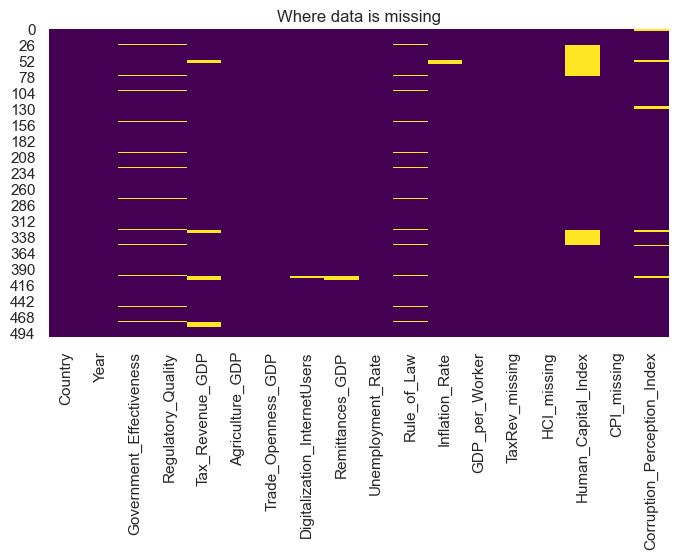

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt 
plt.figure(figsize=(8,4))
sns.heatmap(df_clean.isnull(),cbar=False, cmap='viridis') 
plt.title('Where data is missing')
plt.show()
    


#Visualize outliers

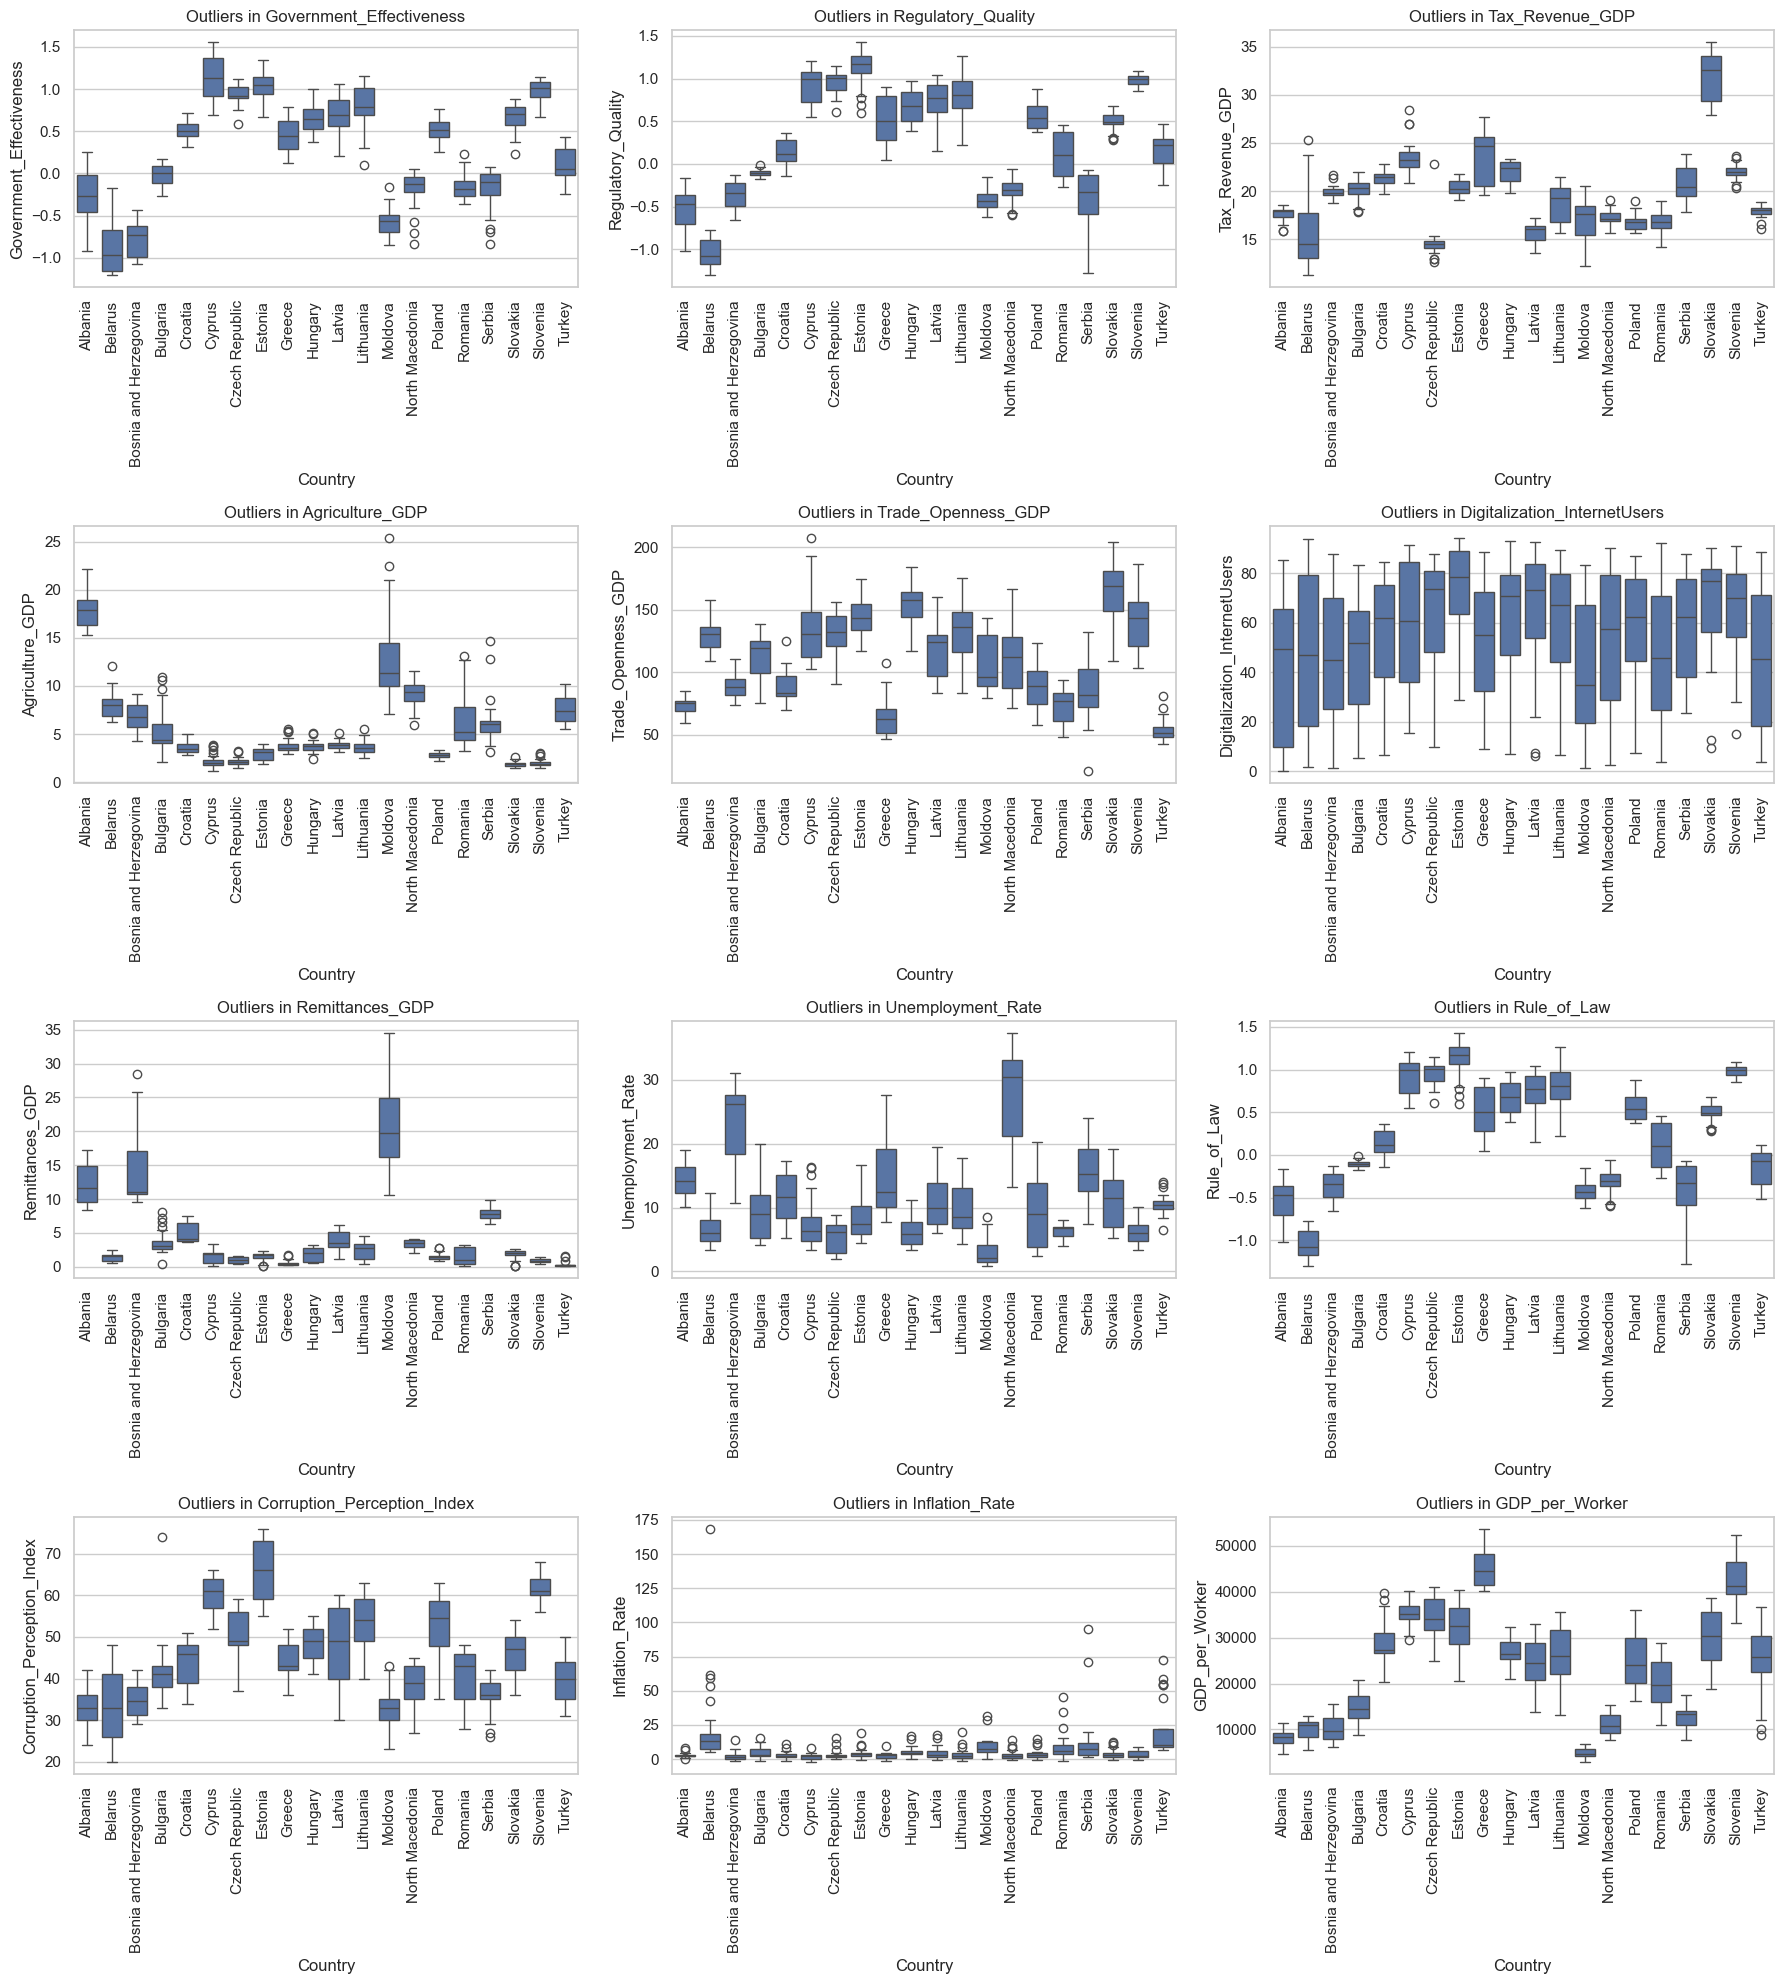

In [148]:
available_numeric_cols = [c for c in numeric_columns if c in df_clean.columns]
sns.set(style="whitegrid")
n_cols = 3
n_rows = int(np.ceil(len(available_numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(available_numeric_cols):
    sns.boxplot(data=df_clean, x="Country", y=col, ax=axes[i])
    axes[i].set_title(f"Outliers in {col}", fontsize=12)
    axes[i].tick_params(axis='x', rotation=90)
for j in range(i + 1, len(axes)): 
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [149]:
# --- IQR outlier counter ---
def count_outliers(series):
    series = series.dropna()
    if len(series) < 4:
        return 0
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return int(((series < lower) | (series > upper)).sum())

outliers_summary = {
    col: df_clean.groupby("Country")[col].apply(count_outliers)
    for col in numeric_columns if col in df_clean.columns
}

outliers_df = pd.DataFrame(outliers_summary).fillna(0).astype(int)
outliers_df["Total_Outliers"] = outliers_df.sum(axis=1)

print("\nTop 10 countries by total IQR outliers:")
display(outliers_df.sort_values("Total_Outliers", ascending=False).head(10))




Top 10 countries by total IQR outliers:


,Government_Effectiveness,Regulatory_Quality,Tax_Revenue_GDP,Agriculture_GDP,Trade_Openness_GDP,Digitalization_InternetUsers,Remittances_GDP,Unemployment_Rate,Rule_of_Law,Corruption_Perception_Index,Inflation_Rate,GDP_per_Worker,Total_Outliers
Country,,,,,,,,,,,,,
Turkey,0,0,2,0,2,0,3,4,0,0,6,2,19
Slovakia,1,3,0,1,0,2,3,0,3,0,3,0,16
Bulgaria,0,1,2,3,0,0,5,0,1,1,1,0,14
Cyprus,0,0,3,5,1,0,0,3,0,0,1,1,14
Czech Republic,1,1,4,2,0,0,0,0,1,0,3,0,12
Serbia,3,0,0,4,1,0,0,0,0,2,2,0,12
North Macedonia,3,2,1,1,0,0,0,0,2,0,3,0,12
Estonia,0,3,0,0,0,0,2,0,3,0,3,0,11
Slovenia,0,0,4,3,0,1,0,0,0,0,0,0,8


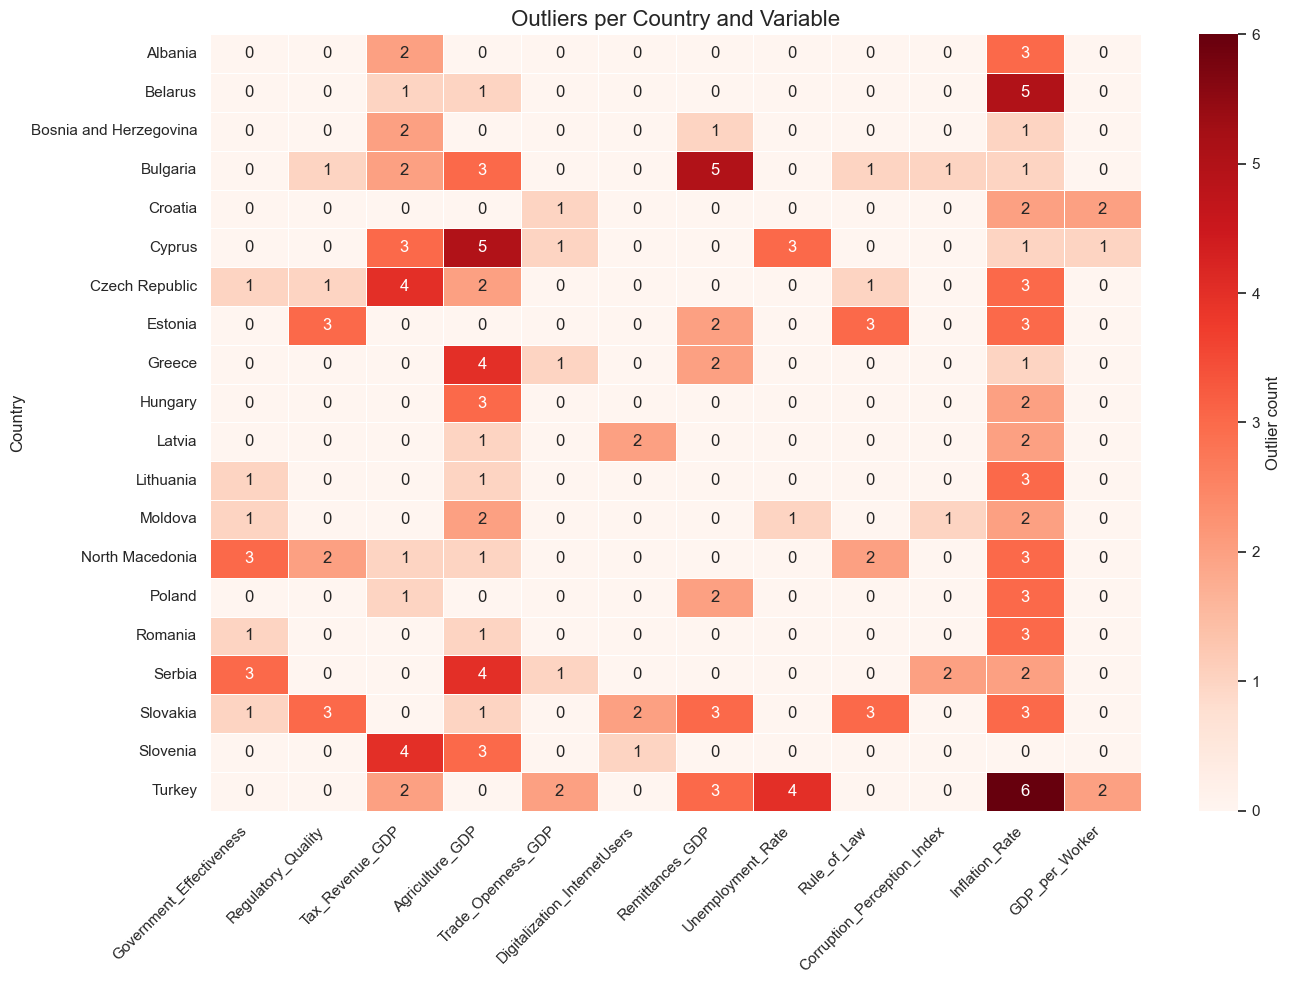

In [150]:
heatmap_data = outliers_df.drop(columns=["Total_Outliers"])
plt.figure(figsize=(14, 10))
sns.set(style="whitegrid")
ax = sns.heatmap(
    heatmap_data,
    cmap="Reds",
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Outlier count"}
)

ax.set_title("Outliers per Country and Variable", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [151]:
# Inspect skewness and extreme quantiles to decide
candidates = ["Inflation_Rate","GDP_per_Worker","Unemployment_Rate","Remittances_GDP",
    "Agriculture_GDP","Trade_Openness_GDP","Tax_Revenue_GDP","Human_Capital_Index","Rule_of_Law",
              "Government_Effectiveness","Regulatory_Quality","Corruption_Perception_Index"]
candidates = [c for c in candidates if c in df_clean.columns]

summary = []
for c in candidates:
    s = df_clean[c].dropna()
    summary.append({
        "variable": c,
        "n": s.shape[0],
        "skew": s.skew(),
        "5%": s.quantile(0.05),
        "95%": s.quantile(0.95),
        "min": s.min(),
        "max": s.max()
    })
pd.DataFrame(summary).sort_values("skew", ascending=False)


,variable,n,skew,5%,95%,min,max
0,Inflation_Rate,494,6.747214,-0.521950,18.187002,-2.096998,168.620236
3,Remittances_GDP,493,2.464574,0.218551,16.687813,0.060912,34.499175
4,Agriculture_GDP,500,1.798279,1.761255,16.229369,1.175795,25.409322
2,Unemployment_Rate,500,1.395132,2.810600,27.491350,0.785000,37.320000
6,Tax_Revenue_GDP,475,1.220060,14.217646,28.509235,11.233546,35.488843
11,Corruption_Perception_Index,483,0.335791,29.000000,64.900000,20.000000,76.000000
1,GDP_per_Worker,500,0.232753,5844.747683,43173.546529,2937.975160,53761.087525
5,Trade_Openness_GDP,500,0.187972,53.280507,166.781167,21.109044,207.632427
8,Rule_of_Law,480,-0.271370,-0.891571,1.107847,-1.303661,1.426389
10,Regulatory_Quality,480,-0.333042,-0.891571,1.107847,-1.303661,1.426389


In [152]:
def safe_log(series, eps=1e-6):
    """Log-transform series safely, add eps to avoid log(0)."""
    return np.log(series + eps)

# Log-transform GDP per worker only
if "GDP_per_Worker" in df_clean.columns:
    # Check if already logged
    if df_clean["GDP_per_Worker"].max() > 100:  # Not logged yet
        df_clean["GDP_per_Worker_original"] = df_clean["GDP_per_Worker"]
        df_clean["GDP_per_Worker"] = safe_log(df_clean["GDP_per_Worker"])
        print("✓ GDP_per_Worker log-transformed")
    else:
        print("✓ GDP_per_Worker already log-transformed")

def winsorize(series, lower_q=0.01, upper_q=0.99):
    s = series.copy()
    lo = s.quantile(lower_q)
    hi = s.quantile(upper_q)
    return np.clip(s, lo, hi)

# Variables that actually need it
winsor_vars = ["Inflation_Rate", "Remittances_GDP"]

for col in winsor_vars:
    if col in df_clean.columns:
        df_clean[f"{col}_orig"] = df_clean[col]
        df_clean[col] = winsorize(df_clean[col], 0.01, 0.99)
def outlier_flags(series, z_thresh=3.0, iqr_mult=1.5):
    z_flag = pd.Series(0, index=series.index)
    iqr_flag = pd.Series(0, index=series.index)
    s = series.dropna()

    if len(s) < 10:  # Not enough data
        return pd.Series(0, index=series.index), pd.Series(0, index=series.index)

    # Z-score
    z = (series - s.mean()) / s.std(ddof=1)
    z_flag = (z.abs() > z_thresh).astype(int)

    # IQR (standard definition)
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - iqr_mult * IQR
    upper = Q3 + iqr_mult * IQR
    iqr_flag = ((series < lower) | (series > upper)).astype(int)

    return z_flag, iqr_flag

# Apply flags
diag_vars = ["Inflation_Rate", "Remittances_GDP", "Agriculture_GDP", "Unemployment_Rate"]

for col in diag_vars:
    if col in df_clean.columns:
        zf, iqrf = outlier_flags(df_clean[col])
        df_clean[f"{col}_zflag"] = zf
        df_clean[f"{col}_iqrflag"] = iqrf
summary_vars = [
    "Inflation_Rate",
    "Remittances_GDP",
    "Agriculture_GDP",
    "Unemployment_Rate",
    "GDP_per_Worker",
    "Trade_Openness_GDP"
]

summary = (
    df_clean[summary_vars]
    .agg(["count", "skew", "min", "max"])
    .T
)

print("\nPost-cleaning distribution summary:")
print(summary)
print("\nWinsorization impact (1st–99th percentiles):")

for col in ["Inflation_Rate", "Remittances_GDP"]:
    if f"{col}_orig" in df_clean.columns:
        changed = (
            (df_clean[col] != df_clean[f"{col}_orig"]) &
            df_clean[col].notna()
        ).sum()
        total = df_clean[col].notna().sum()
        print(f"{col}: {changed}/{total} observations modified ({changed/total*100:.2f}%)")
print("\nOutlier flag counts:")

for col in ["Inflation_Rate", "Remittances_GDP"]:
    zc = df_clean[f"{col}_zflag"].sum()
    iqrc = df_clean[f"{col}_iqrflag"].sum()
    print(f"{col}: Z-flag={zc}, IQR-flag={iqrc}")
print("\nGDP_per_Worker (log) preview:")
print(df_clean["GDP_per_Worker"].describe())





✓ GDP_per_Worker log-transformed

Post-cleaning distribution summary:
                    count      skew        min         max
Inflation_Rate      494.0  3.847324  -1.418953   59.353800
Remittances_GDP     493.0  2.240570   0.076525   27.106004
Agriculture_GDP     500.0  1.798279   1.175795   25.409322
Unemployment_Rate   500.0  1.395132   0.785000   37.320000
GDP_per_Worker      500.0 -0.674981   7.985476   10.892305
Trade_Openness_GDP  500.0  0.187972  21.109044  207.632427

Winsorization impact (1st–99th percentiles):
Inflation_Rate: 10/494 observations modified (2.02%)
Remittances_GDP: 10/493 observations modified (2.03%)

Outlier flag counts:
Inflation_Rate: Z-flag=14, IQR-flag=31
Remittances_GDP: Z-flag=15, IQR-flag=71

GDP_per_Worker (log) preview:
count    500.000000
mean       9.882119
std        0.639225
min        7.985476
25%        9.404906
50%       10.077795
75%       10.400862
max       10.892305
Name: GDP_per_Worker, dtype: float64


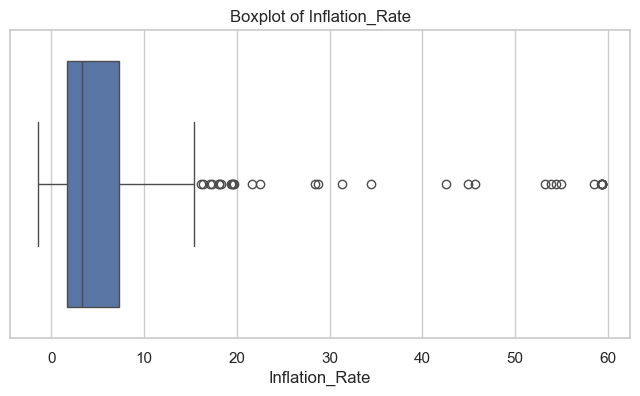

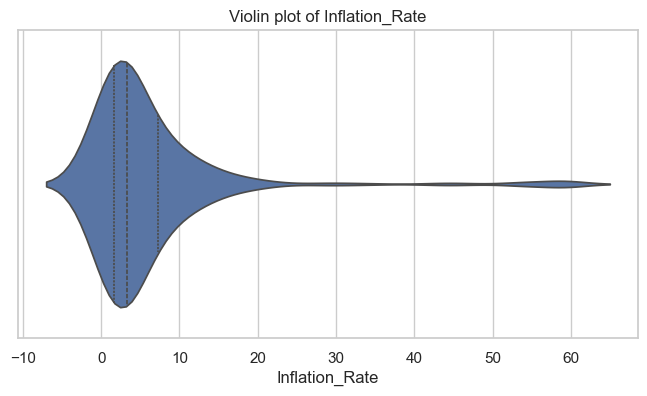

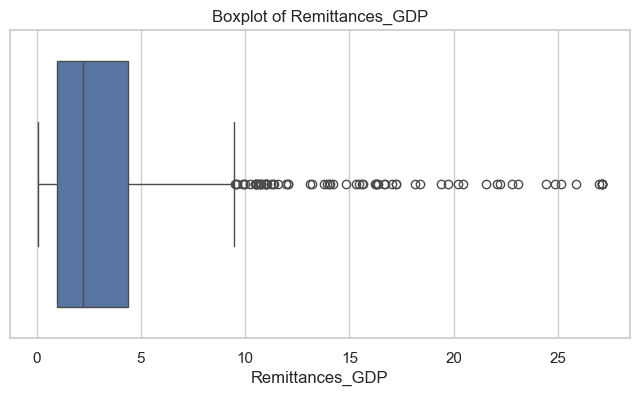

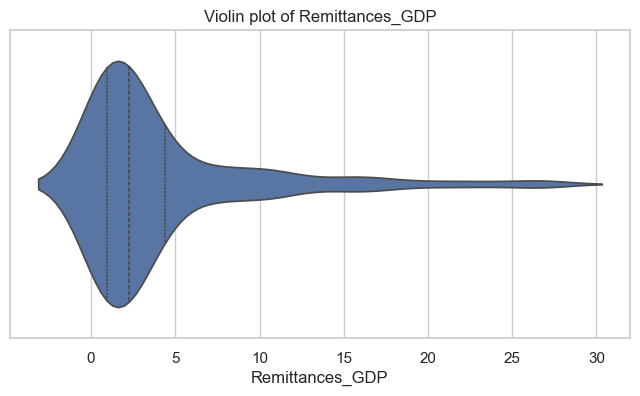

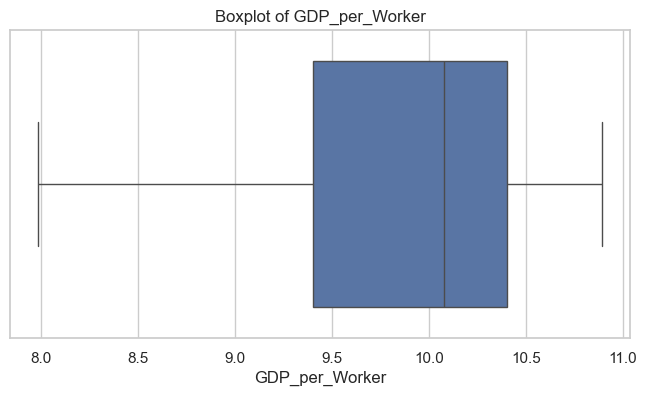

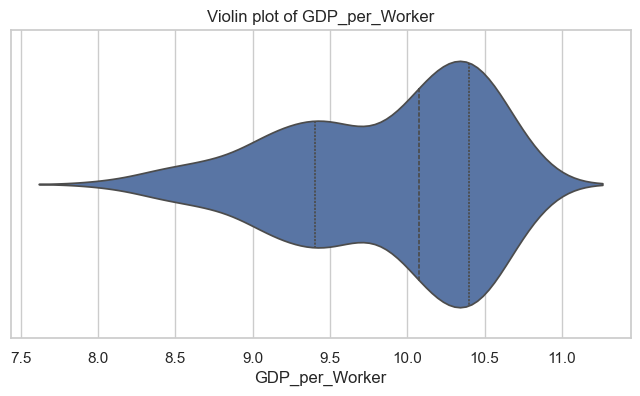

In [153]:

# === 1. Outlier diagnostics / visualization ===
vars_to_plot = ["Inflation_Rate", "Remittances_GDP", "GDP_per_Worker"]

for var in vars_to_plot:
    if var in df_clean.columns:
        plt.figure(figsize=(8,4))
        sns.boxplot(x=df_clean[var])
        plt.title(f"Boxplot of {var}")
        plt.show()

        plt.figure(figsize=(8,4))
        sns.violinplot(x=df_clean[var], inner="quartile")
        plt.title(f"Violin plot of {var}")
        plt.show()


In [154]:
def winsorize(series, lower_q=0.01, upper_q=0.99):
    s = series.copy()
    lo = s.quantile(lower_q)
    hi = s.quantile(upper_q)
    return np.clip(s, lo, hi)

# Variables that are empirically heavy-tailed
winsor_vars = ["Inflation_Rate", "Remittances_GDP"]

for col in winsor_vars:
    if col in df_clean.columns:
        # keep raw version
        df_clean[f"{col}_orig"] = df_clean[col]

        # create winsorized version for main analysis
        df_clean[f"{col}_winsor"] = winsorize(df_clean[col], 0.01, 0.99)

# Diagnostic: how many observations were modified
print("Winsorization impact (1st–99th percentiles):")
for col in winsor_vars:
    if f"{col}_winsor" in df_clean.columns:
        changed = (
            (df_clean[col] != df_clean[f"{col}_winsor"]) &
            df_clean[col].notna()
        ).sum()
        total = df_clean[col].notna().sum()
        print(f"{col}: {changed}/{total} observations modified ({changed/total*100:.2f}%)")



Winsorization impact (1st–99th percentiles):
Inflation_Rate: 10/494 observations modified (2.02%)
Remittances_GDP: 10/493 observations modified (2.03%)


Features used for collinearity diagnostics: ['Inflation_Rate_winsor', 'GDP_per_Worker', 'Unemployment_Rate', 'Remittances_GDP_winsor', 'Agriculture_GDP', 'Trade_Openness_GDP', 'Digitalization_InternetUsers', 'Government_Effectiveness', 'Regulatory_Quality', 'Rule_of_Law', 'Corruption_Perception_Index', 'Human_Capital_Index', 'Tax_Revenue_GDP']


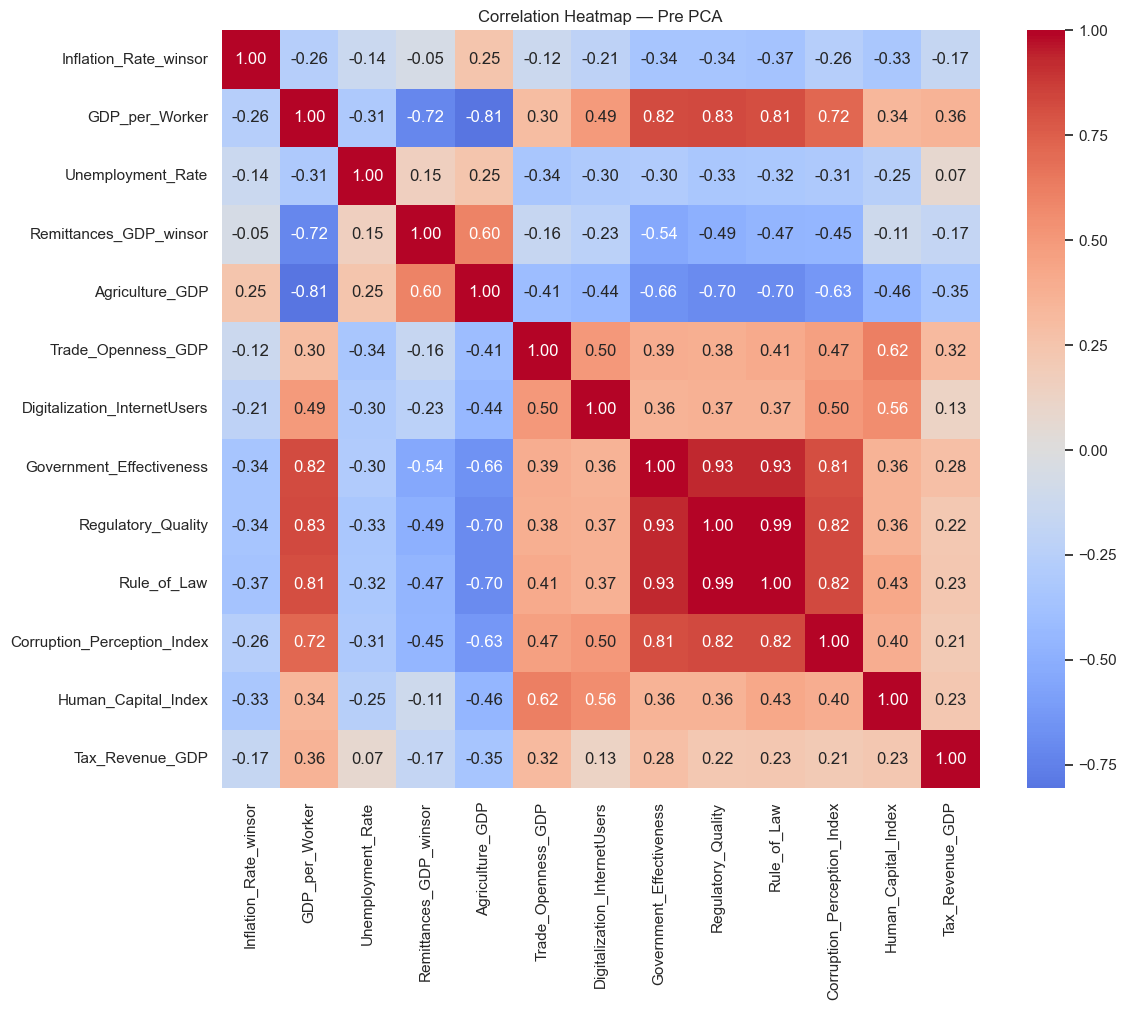

In [155]:
base_vars = [
    "Inflation_Rate","GDP_per_Worker","Unemployment_Rate","Remittances_GDP",
    "Agriculture_GDP","Trade_Openness_GDP","Digitalization_InternetUsers",
    "Government_Effectiveness","Regulatory_Quality","Rule_of_Law",
    "Corruption_Perception_Index","Human_Capital_Index","Tax_Revenue_GDP"
]
# keep only existing columns and prefer *_winsor when available
features = []
for v in base_vars:
    if f"{v}_winsor" in df_clean.columns:
        features.append(f"{v}_winsor")
    elif v in df_clean.columns:
        features.append(v)
# final features list
print("Features used for collinearity diagnostics:", features)

# 2) Correlation heatmap (Pearson) with annotations
plt.figure(figsize=(12,10))
corr = df_clean[features].corr(method="pearson")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap — Pre PCA")
plt.tight_layout()
plt.show()





In [156]:
#split -> Expanding Window-> the year 2000 is kept as the anchor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("="*70)
print("WALK-FORWARD VALIDATION SETUP (EXPANDING WINDOW)")
print("="*70)
start_year = 2000
first_test_year = 2016 #15 years of first training
# Test from 2016 up to 2023 
test_years = range(first_test_year, 2024) 

print(f"\nWalk-forward configuration:")
print(f"  Training Start (Anchor): {start_year}")
print(f"  First Test Year:         {first_test_year} (Training on {start_year}-{first_test_year-1})")
print(f"  Test Years:              {list(test_years)}")
print(f"  Total Splits:            {len(test_years)}")

results = []
# EXPANDING WINDOW LOOP
for test_year in test_years:
    df_train = df_clean[df_clean["Year"] < test_year].copy()
    df_test  = df_clean[df_clean["Year"] == test_year].copy()
    
    print(f"\n--- Split for Test Year: {test_year} ---")
    print(f"  Training Data: {df_train['Year'].min()} to {df_train['Year'].max()} (Rows: {len(df_train)})")
    print(f"  Testing Data:  {df_test['Year'].unique()} (Rows: {len(df_test)})")


WALK-FORWARD VALIDATION SETUP (EXPANDING WINDOW)

Walk-forward configuration:
  Training Start (Anchor): 2000
  First Test Year:         2016 (Training on 2000-2015)
  Test Years:              [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
  Total Splits:            8

--- Split for Test Year: 2016 ---
  Training Data: 2000 to 2015 (Rows: 320)
  Testing Data:  [2016] (Rows: 20)

--- Split for Test Year: 2017 ---
  Training Data: 2000 to 2016 (Rows: 340)
  Testing Data:  [2017] (Rows: 20)

--- Split for Test Year: 2018 ---
  Training Data: 2000 to 2017 (Rows: 360)
  Testing Data:  [2018] (Rows: 20)

--- Split for Test Year: 2019 ---
  Training Data: 2000 to 2018 (Rows: 380)
  Testing Data:  [2019] (Rows: 20)

--- Split for Test Year: 2020 ---
  Training Data: 2000 to 2019 (Rows: 400)
  Testing Data:  [2020] (Rows: 20)

--- Split for Test Year: 2021 ---
  Training Data: 2000 to 2020 (Rows: 420)
  Testing Data:  [2021] (Rows: 20)

--- Split for Test Year: 2022 ---
  Training Data: 2000 

In [157]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
##PCA
print("GOVERNANCE PCA (TRAINING ONLY)")

gov_vars = [
    "Government_Effectiveness",
    "Regulatory_Quality",
    "Rule_of_Law",
    "Corruption_Perception_Index"
]

# -----------------------------
# TRAIN PCA
# -----------------------------
X_gov_train = df_train[gov_vars].dropna()

df_train["Governance_Index"] = np.nan

if len(X_gov_train) > 5:   # ensure enough data
    scaler_gov = StandardScaler()
    X_gov_train_scaled = scaler_gov.fit_transform(X_gov_train)

    pca_gov = PCA(n_components=1)
    gov_pca_train = pca_gov.fit_transform(X_gov_train_scaled)

    df_train.loc[X_gov_train.index, "Governance_Index"] = gov_pca_train[:, 0]

    print(f"✓ PCA variance explained: {pca_gov.explained_variance_ratio_[0]*100:.2f}%")
else:
    print("! Warning: Not enough training data for PCA")
    df_train["Governance_Index"] = np.nan

# -----------------------------
# TEST PCA (
# -----------------------------
X_gov_test = df_test[gov_vars].dropna()
df_test["Governance_Index"] = np.nan

if len(X_gov_test) > 0:
    X_gov_test_scaled = scaler_gov.transform(X_gov_test)
    gov_pca_test = pca_gov.transform(X_gov_test_scaled)
    df_test.loc[X_gov_test.index, "Governance_Index"] = gov_pca_test[:, 0]
    print(f"✓ Test obs with Governance_Index: {df_test['Governance_Index'].notna().sum()}")
else:
    print("! Warning: No valid governance data in test year")





GOVERNANCE PCA (TRAINING ONLY)
✓ PCA variance explained: 91.46%
✓ Test obs with Governance_Index: 20


In [196]:
import statsmodels.api as sm
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize columns
df_train["GDP_per_Worker_resid"] = np.nan
df_test["GDP_per_Worker_resid"] = np.nan

# Define masks for valid data
mask_train = df_train["GDP_per_Worker"].notna() & df_train["Governance_Index"].notna()
mask_test = df_test["GDP_per_Worker"].notna() & df_test["Governance_Index"].notna()

if mask_train.sum() > 10:
    # 1. TRAIN REGRESSION
    # Note: explicit alignment matches indices perfectly
    X_train_reg = sm.add_constant(df_train.loc[mask_train, "Governance_Index"])
    y_train_reg = df_train.loc[mask_train, "GDP_per_Worker"]
    
    model_resid = sm.OLS(y_train_reg, X_train_reg).fit()
    
    # 2. CALCULATE RESIDUALS FOR TRAINING DATA (CRITICAL STEP ADDED)
    # Predicted GDP based on Governance
    preds_train = model_resid.predict(X_train_reg)
    # Actual GDP - Predicted GDP = Residual (The "Economic Health" not explained by Politics)
    df_train.loc[mask_train, "GDP_per_Worker_resid"] = y_train_reg - preds_train
    
    # 3. CALCULATE RESIDUALS FOR TEST DATA
    if mask_test.sum() > 0:
        X_test_reg = sm.add_constant(df_test.loc[mask_test, "Governance_Index"], has_constant='add')
        preds_test = model_resid.predict(X_test_reg)
        df_test.loc[mask_test, "GDP_per_Worker_resid"] = df_test.loc[mask_test, "GDP_per_Worker"] - preds_test
        
    print(f"  ✓ Residuals calculated. Train N={mask_train.sum()}, Test N={mask_test.sum()}")


  ✓ Residuals calculated. Train N=443, Test N=20



Base variables: 10
Missing flags: 0
Features used for collinearity diagnostics: ['Inflation_Rate', 'GDP_per_Worker', 'Unemployment_Rate', 'Remittances_GDP', 'Agriculture_GDP', 'Trade_Openness_GDP', 'Digitalization_InternetUsers', 'Human_Capital_Index', 'Tax_Revenue_GDP']


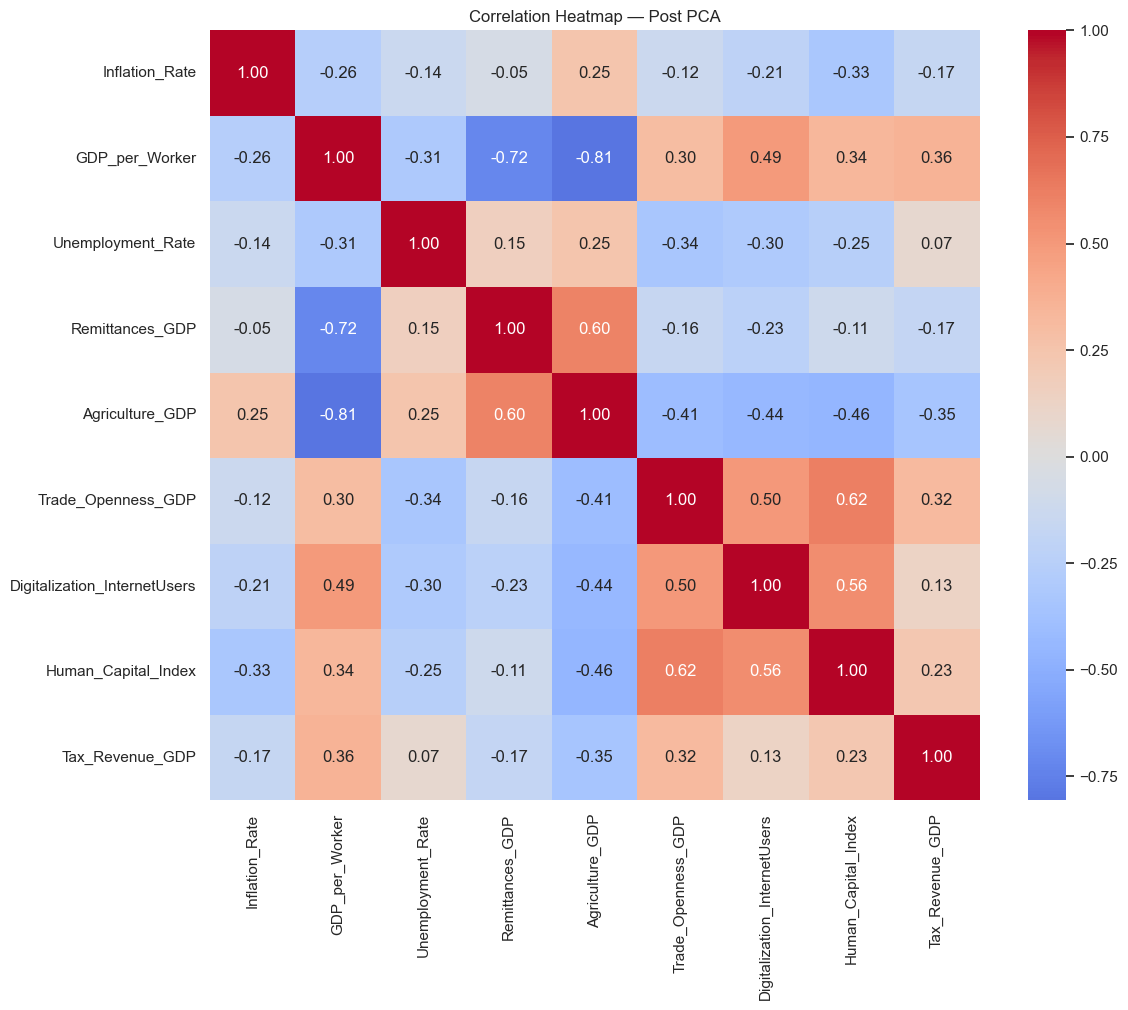

In [159]:

# Base variables (exclude original governance vars)
base_vars = [
    "Inflation_Rate","GDP_per_Worker","Unemployment_Rate","Remittances_GDP",
    "Agriculture_GDP","Trade_Openness_GDP","Digitalization_InternetUsers",
    "Human_Capital_Index","Tax_Revenue_GDP","Governance_Index"
]

# Missing flags (for tree models)
flag_features = [col for col in df_train.columns if '_Missing' in col or '_LargeGap' in col or '_Imputed' in col]

# Final feature list for correlation
features = [f for f in base_vars + flag_features if f in df_clean.columns]

print(f"\nBase variables: {len(base_vars)}")
print(f"Missing flags: {len(flag_features)}")
print("Features used for collinearity diagnostics:", features)

# Correlation heatmap
plt.figure(figsize=(12,10))
corr = df_clean[features].corr(method="pearson")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap — Post PCA")
plt.tight_layout()
plt.show()



In [198]:
print("\n" + "-"*70)
print("DATASET A: TREE MODELS")
print("-"*70)

# 1. Define Input Variables (Using the _winsor names available in df_train)
common_vars = [
    "Inflation_Rate_winsor",
    "Unemployment_Rate",
    "Remittances_GDP_winsor",
    "Agriculture_GDP",
    "Trade_Openness_GDP",
    "Digitalization_InternetUsers",
    "Human_Capital_Index",
    "Tax_Revenue_GDP",
    "Governance_Index",
    "GDP_per_Worker_resid" # <--- Now this exists in df_train!
]

# Add flags if they exist
flag_features = [col for col in df_train.columns if '_Missing' in col or '_LargeGap' in col or '_Imputed' in col]

# Keep only features that exist in the current split
tree_features_in = [f for f in (common_vars + flag_features) if f in df_train.columns]

print(f"Tree model features (input): {len(tree_features_in)}")

# 2. Build DataFrames
df_tree_train = df_train[["Country", "Year"] + tree_features_in].copy()
df_tree_test  = df_test[["Country", "Year"] + tree_features_in].copy()

# 3. Rename Columns
rename_map = {
    "Inflation_Rate_winsor": "Inflation_Rate",
    "Remittances_GDP_winsor": "Remittances_GDP"
}

df_tree_train = df_tree_train.rename(columns=rename_map)
df_tree_test  = df_tree_test.rename(columns=rename_map)
tree_features_out = [rename_map.get(f, f) for f in tree_features_in]

print(f"Training shape (tree): {df_tree_train.shape}")
print(f"NaN in Tree Data: {df_tree_train[tree_features_out].isna().sum().sum()}")
print(df_tree_train.head())


----------------------------------------------------------------------
DATASET A: TREE MODELS
----------------------------------------------------------------------
Tree model features (input): 10
Training shape (tree): (460, 12)
NaN in Tree Data: 145
   Country  Year  Inflation_Rate  Unemployment_Rate  Remittances_GDP  \
0  Albania  2000        0.050018             19.023        16.677034   
1  Albania  2001        3.107588             18.570        17.228110   
2  Albania  2002        7.770526             17.891        16.247386   
3  Albania  2003        0.484003             16.985        15.318730   
4  Albania  2004        2.280019             16.306        15.670685   

   Agriculture_GDP  Trade_Openness_GDP  Digitalization_InternetUsers  \
0        22.179014           61.609261                      0.114097   
1        20.452405           64.247446                      0.325798   
2        19.763916           65.991465                      0.390081   
3        19.807620        

In [202]:
# ============================================================
# DATASET B: ELASTIC NET (Winsorized, Imputed, Scaled)
# ============================================================
print("\n" + "-"*70)
print("DATASET B: ELASTIC NET")
print("-"*70)

# 1. Define Input Variables
elastic_features_in = [
    "Inflation_Rate_winsor",
    "Unemployment_Rate",
    "Remittances_GDP_winsor",
    "Agriculture_GDP",
    "Trade_Openness_GDP",
    "Digitalization_InternetUsers",
    "Human_Capital_Index",
    "Tax_Revenue_GDP",
    "Governance_Index",
    "GDP_per_Worker_resid" 
]

elastic_features_in = [f for f in elastic_features_in if f in df_train.columns]
print(f"Elastic Net numeric features (input): {len(elastic_features_in)}")

# 2. Impute + Scale (Fit on TRAIN only)
imp = SimpleImputer(strategy="median")
scaler = StandardScaler()

# TRAIN
X_train_imp = imp.fit_transform(df_train[elastic_features_in])
X_train_scaled = scaler.fit_transform(X_train_imp)

df_elastic_train = pd.DataFrame(X_train_scaled, columns=elastic_features_in, index=df_train.index)

# TEST
X_test_imp = imp.transform(df_test[elastic_features_in])
X_test_scaled = scaler.transform(X_test_imp)

df_elastic_test = pd.DataFrame(X_test_scaled, columns=elastic_features_in, index=df_test.index)

# 3. Add IDs (Country, Year)
for col in ["Country", "Year"]:
    df_elastic_train[col] = df_train[col].values
    df_elastic_test[col]  = df_test[col].values

# 4. Rename Columns
df_elastic_train = df_elastic_train.rename(columns=rename_map)
df_elastic_test  = df_elastic_test.rename(columns=rename_map)

# 5. Define Final Output Columns & Order
elastic_features_out = [
    "Inflation_Rate", "Unemployment_Rate", "Remittances_GDP", "Agriculture_GDP",
    "Trade_Openness_GDP", "Digitalization_InternetUsers", "Human_Capital_Index",
    "Tax_Revenue_GDP", "Governance_Index", "GDP_per_Worker_resid"
]
elastic_features_out = [f for f in elastic_features_out if f in df_elastic_train.columns]
ordered_cols = ["Country", "Year"] + elastic_features_out

df_elastic_train = df_elastic_train[ordered_cols]
df_elastic_test  = df_elastic_test[ordered_cols]

# 6. Diagnostics
print(f"Training shape (elastic): {df_elastic_train.shape}")
print("NaN in Elastic Data: ", df_elastic_train[elastic_features_out].isna().sum().sum())
print(df_elastic_train.head())




----------------------------------------------------------------------
DATASET B: ELASTIC NET
----------------------------------------------------------------------
Elastic Net numeric features (input): 10
Training shape (elastic): (460, 12)
NaN in Elastic Data:  0
   Country  Year  Inflation_Rate  Unemployment_Rate  Remittances_GDP  \
0  Albania  2000       -0.620037           1.059859         2.181433   
1  Albania  2001       -0.295381           0.997190         2.278819   
2  Albania  2002        0.199735           0.903255         2.105506   
3  Albania  2003       -0.573956           0.777917         1.941395   
4  Albania  2004       -0.383253           0.683983         2.003592   

   Agriculture_GDP  Trade_Openness_GDP  Digitalization_InternetUsers  \
0         3.765751           -1.301035                     -2.019693   
1         3.369120           -1.226871                     -2.011505   
2         3.210962           -1.177844                     -2.009019   
3         3.

In [200]:
# Check VIF on training data
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Use only numeric feature columns (exclude Country, Year)
numeric_cols = [col for col in df_elastic_train.columns if col not in ["Country", "Year"]]
X_vif = df_elastic_train[numeric_cols]

vif_df = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

print("\nVIF (Variance Inflation Factor):")
print(vif_df.to_string(index=False))



VIF (Variance Inflation Factor):
                    Variable      VIF
             Agriculture_GDP 3.109183
            Governance_Index 2.703338
          Trade_Openness_GDP 2.538581
        GDP_per_Worker_resid 2.406307
             Remittances_GDP 2.406051
         Human_Capital_Index 1.930632
Digitalization_InternetUsers 1.841530
             Tax_Revenue_GDP 1.448465
              Inflation_Rate 1.405673
           Unemployment_Rate 1.340362


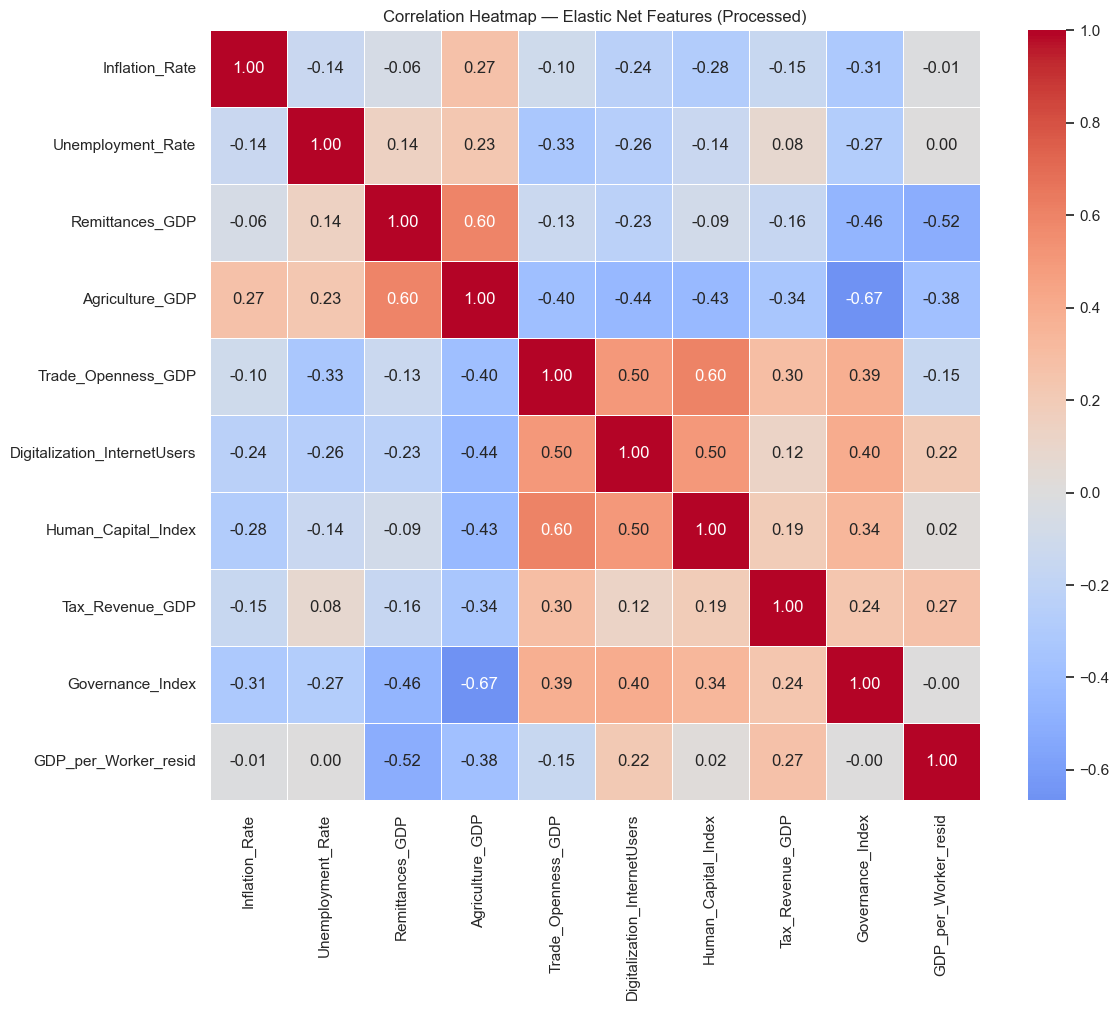

In [201]:
# Correlation heatmap for Elastic Net features (training data)

plt.figure(figsize=(12, 10))
corr_matrix = df_elastic_train.drop(columns=["Country", "Year"]).corr()
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0, 
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap — Elastic Net Features (Processed)")
plt.tight_layout()
plt.savefig("correlation_heatmap_final.png", dpi=300, bbox_inches='tight')
plt.show() 


In [203]:
# ID columns to exclude
id_cols = ["Country", "Year"]

# Get numeric feature columns only
final_numeric_cols = [
    col for col in df_tree_train.columns
    if col not in id_cols and pd.api.types.is_numeric_dtype(df_tree_train[col])
]

print("\n--- ELASTIC NET TRAINING DATA: Numeric Feature Summary ---")

for col in sorted(final_numeric_cols):
    min_val = df_tree_train[col].min()
    max_val = df_tree_train[col].max()
    mean_val = df_tree_train[col].mean()

    print(f"\n{col}: Range={min_val:.4f} to {max_val:.4f}, Mean={mean_val:.4f}")

    # Classification rules
    if 0 <= min_val <= max_val <= 1:
        print("  → PROPORTION (0–1)")
    elif 0 <= min_val <= max_val <= 100:
        print("  → PERCENTAGE (0–100)")
    elif -5 <= min_val <= 5 and -5 <= max_val <= 5:
        print("  → INDEX / SCORE (bounded)")
    elif max_val > 1000 or min_val < -1000:
        print("  → ABSOLUTE VALUE (large scale)")
    else:
        print("  → MIXED SCALE / CHECK SOURCE")

# Optional: repeat for test set
print("\n--- ELASTIC NET TEST DATA: Numeric Feature Summary ---")

for col in sorted(final_numeric_cols):
    min_val = df_tree_test[col].min()
    max_val = df_tree_test[col].max()
    mean_val = df_tree_test[col].mean()

    print(f"\n{col}: Range={min_val:.4f} to {max_val:.4f}, Mean={mean_val:.4f}")

    if 0 <= min_val <= max_val <= 1:
        print("  → PROPORTION (0–1)")
    elif 0 <= min_val <= max_val <= 100:
        print("  → PERCENTAGE (0–100)")
    elif -5 <= min_val <= 5 and -5 <= max_val <= 5:
        print("  → INDEX / SCORE (bounded)")
    elif max_val > 1000 or min_val < -1000:
        print("  → ABSOLUTE VALUE (large scale)")
    else:
        print("  → MIXED SCALE / CHECK SOURCE")




--- ELASTIC NET TRAINING DATA: Numeric Feature Summary ---

Agriculture_GDP: Range=1.1758 to 25.4093, Mean=5.7860
  → PERCENTAGE (0–100)

Digitalization_InternetUsers: Range=0.1141 to 91.5202, Mean=52.2955
  → PERCENTAGE (0–100)

GDP_per_Worker_resid: Range=-1.1677 to 0.8659, Mean=0.0000
  → INDEX / SCORE (bounded)

Governance_Index: Range=-4.7962 to 3.9894, Mean=0.0000
  → INDEX / SCORE (bounded)

Human_Capital_Index: Range=1.9965 to 3.8654, Mean=3.1424
  → PERCENTAGE (0–100)

Inflation_Rate: Range=-1.4182 to 59.2291, Mean=5.9247
  → MIXED SCALE / CHECK SOURCE

Remittances_GDP: Range=0.0767 to 27.0029, Mean=4.3653
  → PERCENTAGE (0–100)

Tax_Revenue_GDP: Range=11.2335 to 35.4098, Mean=19.6766
  → PERCENTAGE (0–100)

Trade_Openness_GDP: Range=21.1090 to 207.6324, Mean=107.8906
  → MIXED SCALE / CHECK SOURCE

Unemployment_Rate: Range=0.7850 to 37.3200, Mean=11.3619
  → PERCENTAGE (0–100)

--- ELASTIC NET TEST DATA: Numeric Feature Summary ---

Agriculture_GDP: Range=1.1791 to 16.2226, 

In [216]:

print("Target variable: Informal Economy Size % of GDP")
df_raw = pd.read_excel("shadow_economy%.xlsx", sheet_name="Historical Data", header=6)

modeling_countries = [
    "Albania", "Belarus", "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Cyprus",
    "Czech Republic", "Estonia", "Greece", "Hungary", "Latvia", "Lithuania",
    "Moldova", "North Macedonia", "Poland", "Romania", "Serbia", "Slovak Republic",
    "Slovenia", "Turkey"
]


df_filtered = df_raw[df_raw["Country"].isin(modeling_countries)].copy()

years_int = list(range(2000, 2025))  
years_str = [str(y) for y in years_int]
df_long = df_filtered.melt(
    id_vars=["Country"], 
    value_vars=value_vars,
    var_name="Year", 
    value_name="Shadow_Economy"
)
df_long["Year"] = df_long["Year"].astype(int)
df_long["Shadow_Economy"] = pd.to_numeric(df_long["Shadow_Economy"], errors='coerce')
df_long = df_long.sort_values(by=["Country", "Year"]).reset_index(drop=True)
# Output
print(df_long.head(75))
print(f"Total rows: {len(df_long)}")
print(f"Countries found: {df_long['Country'].nunique()}")

Target variable: Informal Economy Size % of GDP
                   Country  Year  Shadow_Economy
0                  Albania  2000       51.749985
1                  Albania  2001       51.505030
2                  Albania  2002       51.260075
3                  Albania  2003       48.689982
4                  Albania  2004       49.185031
..                     ...   ...             ...
70  Bosnia and Herzegovina  2020       38.269861
71  Bosnia and Herzegovina  2021       35.790523
72  Bosnia and Herzegovina  2022       34.081121
73  Bosnia and Herzegovina  2023       33.148068
74  Bosnia and Herzegovina  2024       32.070033

[75 rows x 3 columns]
Total rows: 500
Countries found: 20
